In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import math
import folium
from tqdm import tqdm
import rasterio
from rasterio.transform import rowcol
from rasterio.merge import merge
from rasterio.mask import mask
from pyproj import Transformer

import osmium

from sklearn.neighbors import BallTree
from tqdm import tqdm
import time

from sklearn.cluster import DBSCAN

from shapely.ops import unary_union

import osmnx as ox
import networkx as nx

from shapely.geometry import box

from shapely.ops import nearest_points
from shapely.geometry import LineString

In [2]:
# DEFINICJE #

# MAPY #
france_regions_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/regions.geojson" 
france_departments_map_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/refs/heads/master/departements-version-simplifiee.geojson" 

# TRZCIONKA NA WYKRESACH #
plt.rcParams.update({"axes.titlesize": 11.5, "axes.labelsize": 10, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5})

In [5]:
data3 = pd.read_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_all_final.txt', low_memory = False)

ids1 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_transaction_ids.txt", dtype=str)
ids2 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_apartment_one_outbuilding_transaction_ids.txt", dtype=str)
ids3 = np.loadtxt(r"D:\nieruchomosci_ostateczne\samples\one_house_transaction_ids.txt", dtype=str)

features_ids = set(ids1) | set(ids2) | set(ids3) 

1. **gęstość zaludnienia**

In [3]:
tif_files = [
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R3_C19.tif",
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C18.tif",
    "GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C19.tif",
    'GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R5_C19.tif',
    'GHS_POP_E2020_GLOBE_R2023A_54009_1000_V1_0_R4_C20.tif'
]

tif_files = [f"D:\\nieruchomosci_ostateczne\\density\\{tif}" for tif in tif_files]
datasets = [rasterio.open(tif) for tif in tif_files]

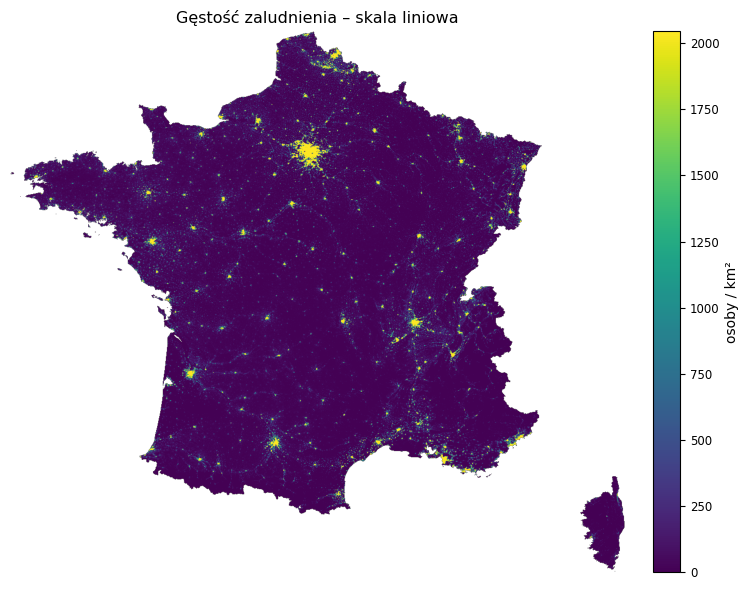

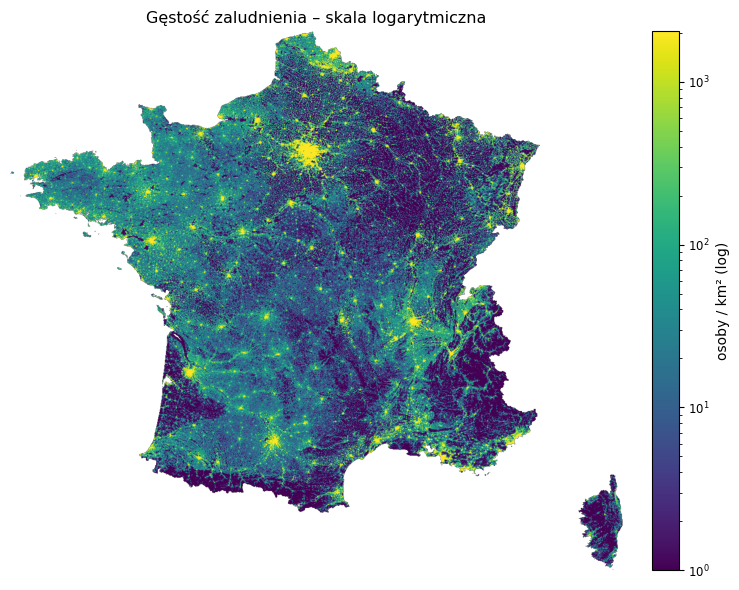

In [5]:
mosaic, mosaic_transform = merge(datasets)

mosaic_meta = datasets[0].meta.copy()
mosaic_meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2], "transform": mosaic_transform})

# zapis mozaiki na dysk (łatwiej potem używać)
out_tif = r"D:\\nieruchomosci_ostateczne\\density\\ghs_pop_fr_mosaic.tif"

with rasterio.open(out_tif, "w", **mosaic_meta) as dst:
    dst.write(mosaic)

france = gpd.read_file(france_regions_map_url)
france_union = france.dissolve()   

with rasterio.open(out_tif) as src:
    france_union = france_union.to_crs(src.crs)
    out_image, out_transform = mask(src, france_union.geometry, crop=True)
    out_meta = src.meta.copy()
    out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})


data_fr = out_image[0].astype(float)
nodata = out_meta.get("nodata", None)

if nodata is not None:
    data_fr[data_fr == nodata] = np.nan

# sensowne vmaxy (jak u Ciebie)
vmax_lin = np.nanpercentile(data_fr, 99)

# ========= 1) WYKRES: SKALA LINIOWA =========
plt.figure(figsize=(8, 6))

im1 = plt.imshow(data_fr, origin="upper", cmap="viridis", vmin=0, vmax=vmax_lin)
plt.title("Gęstość zaludnienia – skala liniowa")
plt.axis("off")

cbar1 = plt.colorbar(im1, fraction=0.046, pad=0.04)
cbar1.set_label("osoby / km²")

plt.tight_layout()
plt.show()


# ========= 2) WYKRES: SKALA LOGARYTMICZNA =========
# Ustalasz dolny próg loga (najniższy kolor). Najczęściej 1 os./km² jest OK.
vmin_log = 1.0

# kopiujemy i "przycinamy" wszystko co <= vmin_log do vmin_log
data_log = data_fr.astype(float).copy()

# jeśli masz NaNy (np. morze) zostawiamy NaNy, a resztę przycinamy:
mask_valid = np.isfinite(data_log)
data_log[mask_valid] = np.clip(data_log[mask_valid], vmin_log, None)

# vmax dla loga (liczymy już na przyciętych danych, żeby nie było problemów)
vmax_log = np.nanpercentile(data_log, 99)

plt.figure(figsize=(8, 6))

im2 = plt.imshow(
    data_log,
    origin="upper",
    cmap="viridis",
    norm=LogNorm(vmin=vmin_log, vmax=vmax_log)
)
plt.title("Gęstość zaludnienia – skala logarytmiczna")
plt.axis("off")

cbar2 = plt.colorbar(im2, fraction=0.046, pad=0.04)
cbar2.set_label("osoby / km² (log)")

plt.tight_layout()
plt.show()


mapowanie gęstości na dane

In [6]:
raster_crs = datasets[0].crs
transformer = Transformer.from_crs("EPSG:4326", raster_crs, always_xy=True)

lon = data3["longitude"].to_numpy()
lat = data3["latitude"].to_numpy()
x, y = transformer.transform(lon, lat)

# kolumna wynikowa
density = np.full(len(data3), np.nan, dtype="float32")

# punkty z danych bierzemy wektorowo
for ds in datasets:
    band = ds.read(1)
    nodata = ds.nodata

    inv = ~ds.transform
    cols, rows = inv * (x, y)
    rows = rows.astype(np.int64)
    cols = cols.astype(np.int64)

    inside = (rows >= 0) & (rows < ds.height) & (cols >= 0) & (cols < ds.width)
    need = inside & np.isnan(density)
    if not np.any(need):
        continue

    vals = band[rows[need], cols[need]]

    good = vals != nodata if nodata is not None else np.isfinite(vals)
    idx_need = np.flatnonzero(need)
    density[idx_need[good]] = vals[good]

data3["population_density"] = density

for ds in datasets:
    ds.close()


2. **France Open Street Map (OSM)**

zapisujemy tylko **wybrane** obiekty z OSM lokalnie

In [7]:
# class POIHandler(osmium.SimpleHandler):
#     def __init__(self):
#         super().__init__()
#         self.rows = []

#         # GŁÓWNE KLUCZE
#         self.relevant_keys = ["amenity", "healthcare", "shop", "leisure", "public_transport", "highway", "railway", "natural", "landuse", "waterway",]

#         # WYSZCZEGÓLNIONE OBIETKY
#         self.amenity_keep = {"school", "kindergarten", "college", "university", "hospital", "clinic", "doctors", "pharmacy",
#             "bus_station", "townhall", "police", "fire_station", "library", "cinema", "theatre", "arts_centre", "community_centre",
#             "restaurant", "cafe", "bar", "pub", "fast_food", "marketplace"}

#         self.healthcare_keep = {"hospital", "clinic", "doctor", "dentist", "centre"}
#         self.shop_keep = {"supermarket", "convenience", "greengrocer", "butcher", "bakery", "department_store", "mall", "chemist"}
#         self.leisure_keep = {"park", "garden", "nature_reserve", "playground", "sports_centre", "pitch", "swimming_pool"}

#         self.natural_values = {"wood","scrub", "heath", "grassland", "wetland", "water", "beach", "coastline"}
#         self.landuse_nature = {"forest", "meadow", "grass", "recreation_ground", "village_green", "allotments"}
#         self.waterway_values = {"river", "stream", "canal"}

#         self.public_transport_keep = {"stop_position", "platform", "station"}
#         self.highway_keep = {"bus_stop"}
#         self.railway_keep = {"station", "halt", "tram_stop", "subway_entrance"}

#     def node(self, n):

#         if not n.location.valid():
#             return

#         lat = n.location.lat
#         lon = n.location.lon

#         for key in self.relevant_keys:
#             if key not in n.tags:
#                 continue

#             value = n.tags[key]

        
#             if key == "amenity" and value not in self.amenity_keep:
#                 continue
#             if key == "healthcare" and value not in self.healthcare_keep:
#                 continue
#             if key == "shop" and value not in self.shop_keep:
#                 continue
#             if key == "leisure" and value not in self.leisure_keep:
#                 continue
#             if key == "natural" and value not in self.natural_values:
#                 continue
#             if key == "landuse" and value not in self.landuse_nature:
#                 continue
#             if key == "waterway" and value not in self.waterway_values:
#                 continue
#             if key == "public_transport" and value not in self.public_transport_keep:
#                 continue
#             if key == "highway" and value not in self.highway_keep:
#                 continue
#             if key == "railway" and value not in self.railway_keep:
#                 continue

#             self.rows.append([lat, lon, key, value, n.timestamp])
#             break



# OSM_PBF_PATH = r"D:\\nieruchomosci_ostateczne\\france-260107.osm.pbf"         
# NPY_OUT_PATH = r"D:\\nieruchomosci_ostateczne\\real_estate_factors_france.npy" # wynik

# handler = POIHandler()

# print("Parsowanie france-latest.osm.pbf")

# handler.apply_file(OSM_PBF_PATH, locations=True)
# arr = np.array(handler.rows, dtype=object)
# np.save(NPY_OUT_PATH, arr)

# print(f"Zapisano do: {NPY_OUT_PATH}")

In [ ]:
# OSM_PBF_PATH = r"D:\nieruchomosci_ostateczne\france-260107.osm.pbf"
# OUT_PARQUET  = r"D:\nieruchomosci_ostateczne\real_estate_factors_france.parquet"
# OUT_NPY      = r"D:\nieruchomosci_ostateczne\real_estate_factors_france.npy"
# GRID_M = 30

# class POIHandler(osmium.SimpleHandler):
#     def __init__(self):
#         super().__init__()
#         self.rows = []

#         self.relevant_keys = ["amenity", "healthcare", "shop", "leisure", "public_transport", "highway", "railway", "natural", "landuse", "waterway"]

#         self.amenity_keep = {
#             "school","kindergarten","college","university",
#             "hospital","clinic","doctors","pharmacy",
#             "bus_station","townhall","police","fire_station",
#             "library","cinema","theatre","arts_centre","community_centre",
#             "restaurant","cafe","bar","pub","fast_food","marketplace"
#         }
#         self.healthcare_keep = {"hospital","clinic","doctor","dentist","centre"}
#         self.shop_keep = {"supermarket","convenience","greengrocer","butcher","bakery","department_store","mall","chemist"}
#         self.leisure_keep = {"park","garden","nature_reserve","playground","sports_centre","pitch","swimming_pool"}

#         self.natural_values = {"wood","scrub","heath","grassland","wetland","water","beach","coastline"}
#         self.landuse_nature = {"forest","meadow","grass","recreation_ground","village_green","allotments"}
#         self.waterway_values = {"river","stream","canal"}

#         self.public_transport_keep = {"stop_position","platform","station"}
#         self.highway_keep = {"bus_stop"}
#         self.railway_keep = {"station","halt","tram_stop","subway_entrance"}

#         # self.building_keep = {"hospital", "school", "university", "train_station"}

#     def _match(self, tags):
#         for key in self.relevant_keys:
#             if key not in tags:
#                 continue
#             value = tags[key]

#             if key == "amenity" and value not in self.amenity_keep: continue
#             if key == "healthcare" and value not in self.healthcare_keep: continue
#             if key == "shop" and value not in self.shop_keep: continue
#             if key == "leisure" and value not in self.leisure_keep: continue
#             if key == "natural" and value not in self.natural_values: continue
#             if key == "landuse" and value not in self.landuse_nature: continue
#             if key == "waterway" and value not in self.waterway_values: continue
#             if key == "public_transport" and value not in self.public_transport_keep: continue
#             if key == "highway" and value not in self.highway_keep: continue
#             if key == "railway" and value not in self.railway_keep: continue

#             return key, value

#         return None

#     def node(self, n):
#         if not n.location.valid():
#             return

#         m = self._match(n.tags)
#         if m is None:
#             return

#         key, value = m
#         name = n.tags.get("name")

#         self.rows.append(["node", int(n.id), n.location.lat, n.location.lon, key, value, name])

#     def way(self, w):
#         m = self._match(w.tags)
#         if m is None:
#             return

#         lats, lons = [], []
#         for nd in w.nodes:
#             if nd.location.valid():
#                 lats.append(nd.location.lat)
#                 lons.append(nd.location.lon)

#         if not lats:
#             return

#         key, value = m
#         lat = float(np.mean(lats))
#         lon = float(np.mean(lons))
#         name = w.tags.get("name")

#         self.rows.append(["way", int(w.id), lat, lon, key, value, name])


# def dedup_pois(df: pd.DataFrame, grid_m: int = 30) -> pd.DataFrame:
#     """
#     Usuwa duplikaty (np. ten sam szpital jako node i jako way).
#     Reguła:
#       - jeśli jest name -> dedup po (key,value,name)
#       - jeśli nie ma name -> dedup po (key,value,grid ~ grid_m metrów)
#       - preferuj way nad node
#     """
#     df = df.copy()

#     # priorytet: way > node
#     pri = {"way": 1, "node": 0}
#     df["pri"] = df["osm_type"].map(pri).fillna(0).astype(int)

#     # grid w stopniach (przybliżenie; do FR wystarcza)
#     g = grid_m / 111_320.0
#     df["g_lat"] = (df["lat"] / g).round().astype("int64")
#     df["g_lon"] = (df["lon"] / g).round().astype("int64")

#     df["name_norm"] = df["name"].fillna("").astype(str).str.strip().str.lower()
#     has_name = df["name_norm"].ne("")

#     df["dedup_key"] = np.where(
#         has_name,
#         df["key"] + "|" + df["value"] + "|" + df["name_norm"],
#         df["key"] + "|" + df["value"] + "|" + df["g_lat"].astype(str) + "|" + df["g_lon"].astype(str),
#     )

#     df = df.sort_values(["dedup_key", "pri"], ascending=[True, False])
#     df = df.drop_duplicates("dedup_key", keep="first")

#     return df.drop(columns=["pri","g_lat","g_lon","name_norm","dedup_key"]).reset_index(drop=True)



# handler = POIHandler()
# handler.apply_file(OSM_PBF_PATH, locations=True)



# df = pd.DataFrame(handler.rows, columns=["osm_type", "osm_id", "lat", "lon", "key", "value", "name"])
# print("Przed dedup:", len(df))

# # df = dedup_pois(df, grid_m=GRID_M)
# # print("Po dedup:", len(df))

# df.to_parquet(OUT_PARQUET, index=False)
# np.save(OUT_NPY, df.to_numpy(dtype=object))

Przed dedup: 5573640


wczytujemy obiekty i robimy ilość ogólnie i szczegółowo infrastruktury w promieniu 100m, 500m i 1000m 

In [2]:
real_estate_factors = np.load("D://nieruchomosci_ostateczne//real_estate_factors_france.npy", allow_pickle=True)
df_factors = pd.DataFrame(real_estate_factors, columns=["osm_type", "osm_id", "lat", "long", "type", "object", "name"])

In [7]:
temp = df_factors.groupby(['lat', 'long', 'object']).filter(lambda g: g.size > 1)

In [13]:
radius_m = 50
R = 6371000.0
radius_rad = radius_m / R

keep_mask = np.ones(len(df_factors), dtype=bool)

# NOT NONE -> WYRZUCAMY PO NAZWIE #

for name, g in df_factors[df_factors["name"].notna()].groupby("name", sort=False):
    if len(g) <= 1:
        continue

    idx = g.index.to_numpy()

    coords = np.deg2rad(df_factors.loc[idx, ["lat", "long"]].to_numpy(dtype=float))
    tree = BallTree(coords, metric="haversine")
    neigh = tree.query_radius(coords, r=radius_rad)

    kept_local = np.zeros(len(idx), dtype=bool)

    for i in range(len(idx)):
        if not keep_mask[idx[i]]:
            continue

        nearby = neigh[i]  # zawiera też i samego
        if np.any(kept_local[nearby]):
            keep_mask[idx[i]] = False
        else:
            kept_local[i] = True

# NONE -> WYRZUCAMY PO OBJECT #

for obj, g in df_factors[df_factors["name"].isna()].groupby("object", sort=False):
    if len(g) <= 1:
        continue

    idx = g.index.to_numpy()

    coords = np.deg2rad(df_factors.loc[idx, ["lat", "long"]].to_numpy(dtype=float))
    tree = BallTree(coords, metric="haversine")
    neigh = tree.query_radius(coords, r=radius_rad)

    kept_local = np.zeros(len(idx), dtype=bool)

    for i in range(len(idx)):
        if not keep_mask[idx[i]]:
            continue

        nearby = neigh[i]
        if np.any(kept_local[nearby]):
            keep_mask[idx[i]] = False
        else:
            kept_local[i] = True



df_factors = df_factors[keep_mask].copy()

KeyboardInterrupt: 

In [ ]:

df_factors = df_factors.drop_duplicates(subset=['lat', 'long', 'object'])
df_factors["lat"] = df_factors["lat"].astype(float)
df_factors["long"] = df_factors["long"].astype(float)

object_types = {'public_transport': 'public_transport', 'shop': 'shop', 'amenity': 'amenity', 'highway': 'public_transport', 'railway': 'public_transport',
                'leisure': 'amenity', 'healthcare': 'healthcare', 'natural': 'natural', 'landuse': 'natural', 'waterway': 'natural'}

df_factors['type'] = df_factors.type.replace(object_types)

amenity_as_healthcare = {"hospital", "clinic", "doctors", "doctor", "pharmacy", "dentist"}
mask = (df_factors["type"] == "amenity") & (df_factors["object"].isin(amenity_as_healthcare))
df_factors.loc[mask, "type"] = "healthcare"

data_coords = np.radians(data3.loc[data3.transaction_id.isin(features_ids), ["latitude", "longitude"]])
services_coords = np.radians(df_factors[["lat", "long"]])

tree = BallTree(services_coords, metric='haversine')

radius_100 = 0.1 / 6371 # promień 100m
radius_500 = 0.5 / 6371 # promień 500m
radius_1000 = 1 / 6371 # promień 1000m

In [ ]:
indices_100 = tree.query_radius(data_coords, r=radius_100)
indices_500 = tree.query_radius(data_coords, r=radius_500)
indices_1000 = tree.query_radius(data_coords, r=radius_1000)

In [ ]:
types = df_factors["type"].to_numpy()
uniq = df_factors["type"].unique()
types_to_count = [t for t in uniq if pd.notna(t)]

for t in types_to_count:
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_100"] = np.fromiter((np.sum(types[x] == t) for x in indices_100), dtype=np.uint16, count=len(indices_100))
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_500"] = np.fromiter((np.sum(types[x] == t) for x in indices_500), dtype=np.uint16, count=len(indices_500))
    data3.loc[data3.transaction_id.isin(features_ids), f"n_factors_{t}_1000"] = np.fromiter((np.sum(types[x] == t) for x in indices_1000), dtype=np.uint16, count=len(indices_1000))


In [ ]:
# zliczamy liczbe obiektów w każdym z zakresów (później podzielimy na typy)

data3.loc[data3.transaction_id.isin(features_ids), 'n_factors_all_100'] = np.array([len(x) for x in indices_100])
data3.loc[data3.transaction_id.isin(features_ids), 'n_factors_all_500']= np.array([len(x) for x in indices_500])
data3.loc[data3.transaction_id.isin(features_ids),'n_factors_all_1000']= np.array([len(x) for x in indices_1000])

odległość do najbliższego szpitala/szkoły/środka transportu/sklepu dla Paryża i okolic

In [8]:
objects = {'hospital': ['hospital'], 'school': ["university", "college", 'school'], 'transport': ['subway_entrance', 'bus_stop', 'tram_stop'], 'shop': ['supermarket']}

chosen_object = 'hospital'

# wczytujemy graf
places = ["Paris, France", "Hauts-de-Seine, France", "Seine-Saint-Denis, France", "Val-de-Marne, France"]
G = ox.graph_from_place(places, network_type="walk")

In [9]:
paris_mask = (data3["department_code"].isin(["75", "92", "93", "94"])) & (data3["transaction_id"].isin(features_ids))

chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]), ['lat', 'long']].to_numpy()
paris_coords = data3.loc[paris_mask, ['latitude', 'longitude']].to_numpy()

tree_chosen_object = BallTree(np.radians(chosen_object_coords), metric='haversine')
dist, ind = tree_chosen_object.query(np.radians(paris_coords), k = 1)

~ 10h wyliczeń dla 1 typu 

In [ ]:
dist_chosen_object_all = []

estate_nodes = ox.distance.nearest_nodes(G, paris_coords[:,1], paris_coords[:,0])
object_nodes = ox.distance.nearest_nodes(G, chosen_object_coords[:,1], chosen_object_coords[:,0])

for i in tqdm(range(len(paris_coords)), desc="Liczenie tras do szpitali"):
    
    estate_node = estate_nodes[i]
    object_node = object_nodes[ind[i][0]]

    try:
        route_len_m = nx.shortest_path_length(G, estate_node, object_node, weight="length")
    except nx.NetworkXNoPath:
        route_len_m = np.nan

    dist_chosen_object_all.append(route_len_m)


data3.loc[paris_mask, f'closest_{chosen_object}_dist'] = dist_chosen_object_all


In [32]:
# PRZYKŁAD: wizualizujemy trasę na pieszo do najbliższych usług z zadanej lokalizacji mieszkania #

idx = np.random.choice(len(paris_coords), size=10, replace=False)
est_coords = paris_coords[idx]
hospitals_coords = chosen_object_coords[ind[idx][:, 0]]

quick_map = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

for k in range(len(est_coords)):

    lat, lon = est_coords[k]
    hosp_lat, hosp_lon = hospitals_coords[k]

    folium.Marker(location=[lat, lon], icon=folium.Icon(color='blue')).add_to(quick_map)
    folium.Marker(location=[hosp_lat, hosp_lon], icon=folium.Icon(color='purple')).add_to(quick_map)
    
    est_node = ox.distance.nearest_nodes(G, lon, lat)
    hosp_node = ox.distance.nearest_nodes(G, hosp_lon, hosp_lat)
    route_nodes = ox.routing.shortest_path(G, est_node, hosp_node, weight="length")


    start_lat, start_lon = G.nodes[est_node]["y"], G.nodes[est_node]["x"]
    end_lat, end_lon     = G.nodes[hosp_node]["y"],   G.nodes[hosp_node]["x"]
    route_latlon = [(G.nodes[n]["y"], G.nodes[n]["x"]) for n in route_nodes]
    
    folium.PolyLine(locations=[(lat, lon), (start_lat, start_lon)], weight=6, color = 'red').add_to(quick_map)
    folium.PolyLine(locations=route_latlon, weight=6, color = 'red').add_to(quick_map)
    folium.PolyLine(locations=[(end_lat, end_lon), (hosp_lat, hosp_lon)], weight=6, color = 'red').add_to(quick_map)

quick_map.save(f"hospitals.html")


In [10]:
chosen_object_coords = df_factors.loc[df_factors['object'].isin(objects[chosen_object]),:]
m = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

for _, row in chosen_object_coords.iterrows():
    folium.CircleMarker(
        location=[row.lat, row.long],
        popup=row["name"],
        radius=3,
        fill=True
    ).add_to(m)

m.save("hospitals_all.html")

In [ ]:
# PRZYKŁAD: obiekty w pobliżu przykładowego mieszkania #

colours = {'public_transport': 'blue', 'shop': 'purple', 'amenity': 'orange', 'healthcare': 'darkred', 'natural': 'green'}
subset = data3[data3.transaction_id.isin(features_ids)].reset_index(drop=True)

# losujemy 5 mieszkań w Paryżu
points1 = subset[(subset.department_code == "75") & (subset.local_type == 'Apartment') & (subset.n_factors_all_500 > 1000)].sample(5)

# losujemy 5 mieszkań we Francji
points2 = subset[(subset.department_code != "75") & (subset.local_type == 'Apartment')].sample(5)

points = pd.concat([points1, points2])
fr_map = folium.Map(location=[48.8566, 2.3522], zoom_start=12)

for k, (indeks, row_flat) in enumerate(points.iterrows(), start=1):
    
    latitude  = row_flat['latitude']
    longitude = row_flat['longitude']

    folium.Marker([latitude, longitude], icon=folium.Icon(color='red'), popup=f"{row_flat.local_type}: {row_flat.price_m_2:.0f} EUR / m^2").add_to(fr_map)
    folium.Circle(location=[latitude, longitude], radius=500, color="purple", fill=True, fill_opacity=0.15).add_to(fr_map)

    for i in indices_500[indeks]:

        row = df_factors.loc[i]
        lat = row['lat']
        lon = row['long']
        t = row['type']

        folium.CircleMarker(location=[lat, lon], radius=5, color=colours[t], fill=True, fill_color=colours[t], fill_opacity=1, popup=f"{t}: {row['object']}").add_to(fr_map)


fr_map.save(f"uslugi_mieszkanie.html")

3. **dystans do najbliższych miast (i nie tylko)**

wyszczególniamy top najważniejszych miast i szacujemy odległość do nich w linii prostej (uwzględniając zakrzywienie linii)

In [ ]:
big_cities = [
    ("Paris", 48.85341, 2.34880),
    ("Marseille", 43.29695, 5.38107),
    ("Lyon", 45.74846, 4.84671),
    ("Toulouse", 43.60426, 1.44367),
    ("Nice", 43.70313, 7.26608),
    ("Nantes", 47.21725, -1.55336),
    ("Rennes", 48.11727, -1.67779),
    ("Strasbourg", 48.58392, 7.74553),
    ("Montpellier", 43.61093, 3.87635),
    ("Bordeaux", 44.84044, -0.58050),
    ("Lille", 50.63297, 3.05858),
    ("Brest", 48.39029, -4.48628),
    ("Cannes", 43.55135, 7.01275),
    ("Calais", 50.95194, 1.85635),
    ("Le Havre", 49.49346, 0.10785),
    ("Saint-Malo", 48.64738, -2.00877),
    ("La Rochelle", 46.16308, -1.15222),
    ("Biarritz", 43.48012, -1.55558),
    ("Toulon", 43.12442, 5.92836),
    ("Perpignan", 42.69764, 2.89541),

    # nowe
    ("Grenoble", 45.18853, 5.72452),
    ("Dijon", 47.32205, 5.04148),
    ("Angers", 47.47842, -0.56317),
    ("Tours", 47.39414, 0.68484),
]

city_coords = np.array([(city[1], city[2]) for city in big_cities])
data_coords = data3[["latitude", "longitude"]].values

city_rad = np.radians(city_coords)
data_rad = np.radians(data_coords)

tree = BallTree(city_rad, metric='haversine')
dist_rad, ind = tree.query(data_rad, k=1)
dist_km = dist_rad[:, 0] * 6371.0
idx = ind[:, 0]

city_names = np.array([c[0] for c in big_cities])

data3["nearest_big_city"] = city_names[idx]
data3["dist_to_big_city_km"] = dist_km
data3["nearest_city_idx"] = idx

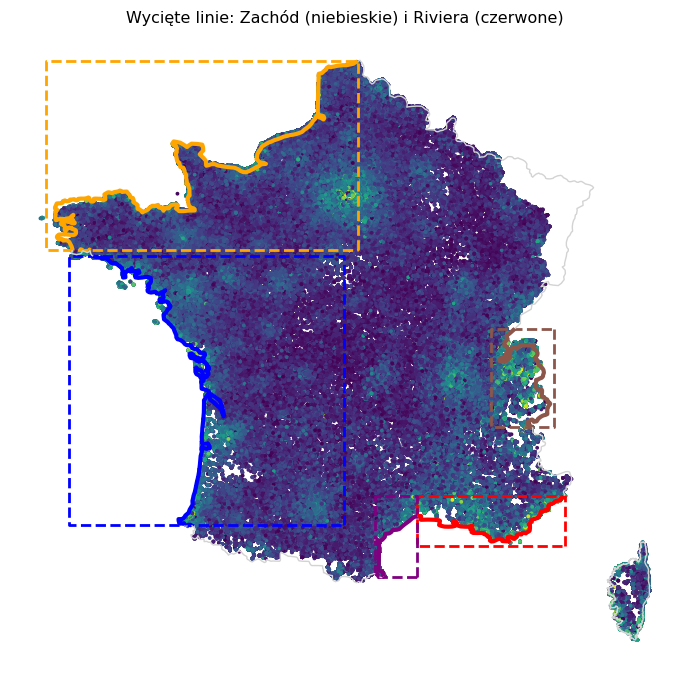

In [59]:
subset = data3[(data3.transaction_id.isin(features_ids)) & (~data3.price_m_2.isin([np.inf, np.nan]))]
subset = subset[subset.price_m_2 < subset.price_m_2.quantile(0.95)]

subset_points = gpd.GeoDataFrame(subset[['price_m_2']], geometry=gpd.points_from_xy(subset.longitude, subset.latitude), crs='EPSG:4326')


fr = gpd.read_file(r"D:\nieruchomosci_ostateczne\coastline\geoBoundaries-FRA-ADM0-all\geoBoundaries-FRA-ADM0.shp").to_crs(4326)

fr_boundary = fr.boundary.iloc[0]

bb_riv  = box(3.96, 42.95, 7.52, 43.79)
bb_lion = box(2.95, 42.42, 3.96, 43.79)
bb_west = box(-4.44, 43.29, 2.2, 47.82)
bb_north = box(-5.0, 47.92, 2.53, 51.10)
bb_border = box(5.73, 46.60, 7.26, 44.94)

riviera_line = gpd.GeoSeries([fr_boundary.intersection(bb_riv)], crs= "EPSG:4326").explode(index_parts = False)
lion_line = gpd.GeoSeries([fr_boundary.intersection(bb_lion)], crs= "EPSG:4326").explode(index_parts = False)
west_line = gpd.GeoSeries([fr_boundary.intersection(bb_west)], crs= "EPSG:4326").explode(index_parts = False)
north_line = gpd.GeoSeries([fr_boundary.intersection(bb_north)], crs= "EPSG:4326").explode(index_parts = False)
border_line = gpd.GeoSeries([fr_boundary.intersection(bb_border)], crs= "EPSG:4326").explode(index_parts = False)


fr_poly_2154 = fr.to_crs(2154).geometry.iloc[0] 


# WYKRES #

# mapa 
fig, ax = plt.subplots(figsize=(7, 9))
gpd.GeoSeries([fr_boundary], crs=4326).plot(ax=ax, color="lightgray", edgecolor="black", linewidth=1)

# punkty 
subset_points.plot(ax=ax, column='price_m_2', cmap='viridis', markersize=3)

# wyznaczone granice 
west_line.plot(ax=ax, color="blue", linewidth=3)
north_line.plot(ax=ax, color="orange", linewidth=3)
riviera_line.plot(ax=ax, color="red", linewidth=3)
lion_line.plot(ax=ax, color='purple', linewidth=3)
border_line.plot(ax=ax, color='tab:brown', linewidth=3)

# wizualizacja jak wyciągamy granice - boksami
gpd.GeoSeries([bb_riv], crs=4326).plot(ax=ax, facecolor="none", edgecolor="red", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_lion], crs=4326).plot(ax=ax, facecolor="none", edgecolor="purple", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_west], crs=4326).plot(ax=ax, facecolor="none", edgecolor="blue", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_north], crs=4326).plot(ax=ax, facecolor="none", edgecolor="orange", linestyle="--", linewidth=2)
gpd.GeoSeries([bb_border], crs=4326).plot(ax=ax, facecolor="none", edgecolor="tab:brown", linestyle="--", linewidth=2)

ax.set_axis_off()
ax.set_title("Wycięte linie: Zachód (niebieskie) i Riviera (czerwone)")
plt.tight_layout()
plt.show()


szacujemy odległość w linii prostej do każdego z wybrzeży i określamy minimalną odległość + które wybrzeże + zmienne indykatorowe określające jak blisko jesteśmy danego brzegu

In [75]:
geom_points = gpd.GeoSeries(gpd.points_from_xy(data3.longitude, data3.latitude), crs="EPSG:4326").to_crs(2154)

df_borders = pd.DataFrame()

df_borders['north'] = geom_points.geometry.distance(north_line.to_crs(2154).iloc[0]) / 1000
df_borders['west'] = geom_points.geometry.distance(west_line.to_crs(2154).iloc[0]) / 1000 
df_borders['riviera'] = geom_points.geometry.distance(riviera_line.to_crs(2154).iloc[0]) / 1000
df_borders['lion'] = geom_points.geometry.distance(lion_line.to_crs(2154).iloc[0]) / 1000
df_borders['borderrrr'] = geom_points.geometry.distance(border_line.to_crs(2154).iloc[0]) / 1000

df_borders['min_border_dist'] = df_borders.min(axis = 1)
df_borders['border'] = df_borders.idxmin(axis=1)

for thr in [1, 5, 20]:
    df_borders[f"within_{thr}km_border"] = df_borders.min_border_dist <= thr


cols = ['min_border_dist', 'border', 'within_1km_border', 'within_5km_border', 'within_20km_border']
data3[cols] = df_borders[cols].values

dict_lines = {'north': north_line, 'west': west_line, 'riviera': riviera_line, 'lion': lion_line, 'borderrrr': border_line}

C:\Users\jpiec\AppData\Local\Temp\ipykernel_27672\2628428204.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  p_on_coast = nearest_points(POINT, line.to_crs(2154).unary_union)[1]
C:\Users\jpiec\AppData\Local\Temp\ipykernel_27672\2628428204.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


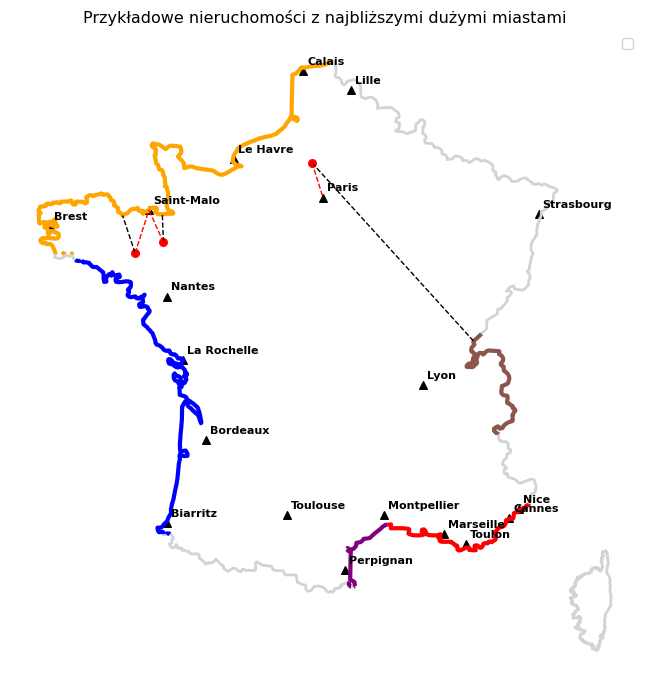

In [77]:
# PRZYKŁAD: odleglość nieruchomości od dużych miast (wybieramy mieszkania daleko od miast, żeby uwypuklić algorytm) #


filtered = data3[data3["dist_to_big_city_km"] >= 50]
points = filtered.sample(3, random_state=42).copy()
nearest_city_idx_sample = points["nearest_city_idx"].values
nearest_border_sample = points['border'].values

fig, ax = plt.subplots(figsize=(7, 7))
gpd.GeoSeries([fr_boundary], crs=4326).plot(ax=ax, color="lightgray", edgecolor="blue", linewidth=2)

# MIASTA #

city_points = gpd.GeoSeries(gpd.points_from_xy(city_coords[:, 1], city_coords[:, 0]), crs="EPSG:4326")
city_points_2154 = city_points.to_crs(2154)
city_points.plot(ax=ax, markersize=30, marker="^", color="black")

for name, lat, lon in big_cities:
    ax.text(lon + 0.1, lat + 0.1, name, fontsize=8, fontweight="bold")

# NIERUCHOMOŚCI #
    
flat_points = gpd.GeoSeries(gpd.points_from_xy(points.longitude, points.latitude), crs="EPSG:4326")
flat_points_2154 = flat_points.to_crs(2154)
flat_points.plot(ax=ax, markersize=30, marker="o", color='red')

lines2154, lines_cities2154 = [], []
for k in range(len(flat_points_2154)):
    
    POINT = flat_points_2154[k]

    line = dict_lines[nearest_border_sample[k]]
    p_on_coast = nearest_points(POINT, line.to_crs(2154).unary_union)[1] 
    
    lines2154.append(LineString([POINT, p_on_coast]))
    lines_cities2154.append(LineString([POINT, city_points_2154.iloc[nearest_city_idx_sample[k]]]))


# Wizualizacja wybranych granic #
north_line.plot(ax=ax, color="orange", linewidth=3)
west_line.plot(ax=ax, color="blue", linewidth=3)
riviera_line.plot(ax=ax, color="red", linewidth=3)
lion_line.plot(ax=ax, color="purple", linewidth=3)
border_line.plot(ax=ax, color="tab:brown", linewidth=3)

# Wizualizacja odległości w linii prostej #
gpd.GeoSeries(lines2154, crs=2154).to_crs(4326).plot(ax=ax, color="black", linewidth=1, linestyle="--")
gpd.GeoSeries(lines_cities2154, crs=2154).to_crs(4326).plot(ax=ax, color="red", linewidth=1, linestyle="--")


ax.set_title("Przykładowe nieruchomości z najbliższymi dużymi miastami")
ax.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

#data3 = data3.drop(columns = "nearest_city_idx")

4. **czynniki makroekonomiczne**

In [ ]:
HPI = pd.read_csv('D:\\nieruchomosci_ostateczne\\data\\makroekonomia\\hpi.csv', delimiter = ";").iloc[6:-28]

HPI.columns = ['Label', 'hpi', 'Code']
HPI['hpi'] = pd.to_numeric(HPI['hpi'], errors='coerce')
HPI['year'] = HPI['Label'].astype(str).str[:4].astype(int)
HPI = HPI.sort_values('Label')
HPI['quarter'] = np.arange(len(HPI)) % 4 + 1

# punkt referencyjny = średnia z 2017
base_2017 = HPI.loc[HPI['year'] == 2017, 'hpi'].mean()
HPI['hpi'] = 100 * HPI['hpi'] / base_2017

# data3 = data3.merge(HPI[['hpi', 'year', 'quarter']], how='left', on=['year', 'quarter'])

hpi_key = (HPI["year"].astype("int32") * 10 + HPI["quarter"].astype("int32"))
hpi_map = pd.Series(HPI["hpi"].to_numpy(dtype="float32"), index=hpi_key).groupby(level=0).mean()

data_key = (data3["year"].astype("int32") * 10 + data3["quarter"].astype("int32"))
data3["hpi"] = data_key.map(hpi_map).astype("float32")

# cena przeskalowana
data3['price_adj'] = data3['property_value'] * (100 / data3['hpi'])
data3['price_m_2_adj'] = data3['price_m_2'] * (100 / data3['hpi'])

zapis danych

In [ ]:
data3.to_csv('D:\\nieruchomosci_ostateczne\\samples\\sample_enhanced_final.txt', index=False)